<a href="https://colab.research.google.com/github/deartoms/python/blob/main/day10_practice1_%EC%B6%94%EB%A1%A0_%EC%98%B5%EC%85%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# YOLO 추론 옵션

In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.5 MB/s eta 0:00:00


In [ ]:
!apt-get -qq install -y fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
from ultralytics import YOLO
import urllib.request, os, time

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
# 감지 결과 이미지 출력 함수
def show(r, title=""):
  plt.figure(figsize=(5, 6))
  plt.imshow(r.plot()[:, :, ::-1]) # r.plot()= BGR -> RGB로 뒤집기
  plt.axis("off")
  if title:
    plt.title(title)
  plt.show()

In [ ]:
BUS_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
if not os.path.exists("bus.jpg"):
  urllib.request.urlretrieve(BUS_URL, "bus.jpg")
  print("bus.jpg 다운로드 완료 (재실행 시 재사용)")

bus.jpg 다운로드 완료 (재실행 시 재사용)


yolo11n.pt: 파라미터 2.6M | 추론 108ms | 감지 5개


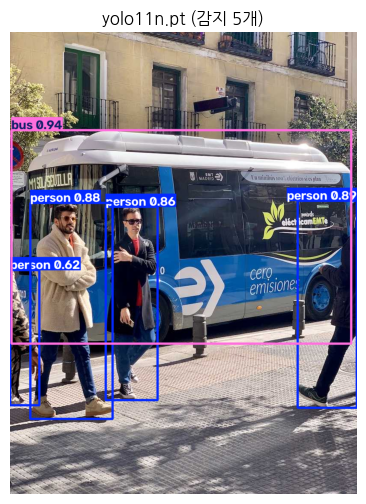

yolo11s.pt: 파라미터 9.5M | 추론 156ms | 감지 5개


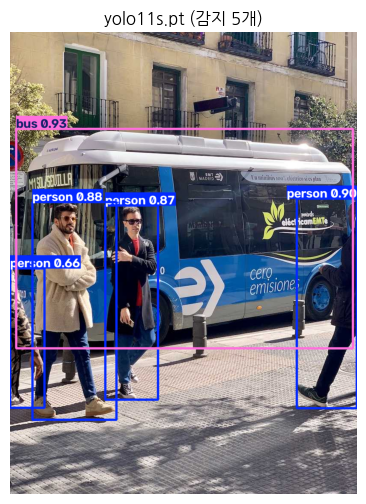

In [ ]:
# 셀 1. 모델 크기 - n vs s 실축 비교
# yolo11n < s < m < l < x (커질수록 정확up↑ 속도down↓)
# nano : 파라미터 2.6M 모바일 실시간
# small: 파라미터 9.5M 서버에서 무난
#m/l/x - GPU 서버급

for name in ["yolo11n.pt", "yolo11s.pt"]:
  model = YOLO(name)
  t0 = time.time()
  r = model("bus.jpg", verbose=False)[0]
  dt = (time.time() - t0) * 1000
  n_params = sum(p.numel() for p in model.model.parameters()) # 홈 파라미터 수 #model.model.parameters()각 층의 가중치·편향이 텐서 형태로 나온다. numel() 그 텐서 하나에 튼 숫자(=파라미터) 개수
  print(f"{name}: 파라미터 {n_params/1e6:.1f}M | 추론 {dt:.0f}ms | 감지 {len(r.boxes)}개")
  show(r, f"{name} (감지 {len(r.boxes)}개)")


[conf threshold]
 conf=0.1  -> 6개 ['bus', 'person', 'person', 'person', 'person', 'skateboard']


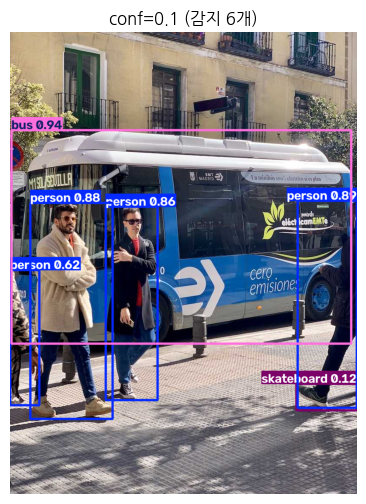

 conf=0.25 -> 5개 ['bus', 'person', 'person', 'person', 'person']


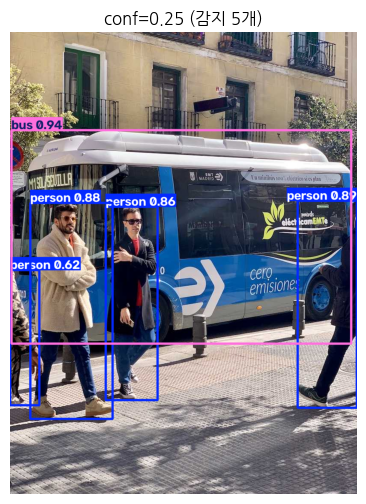

 conf=0.5  -> 5개 ['bus', 'person', 'person', 'person', 'person']


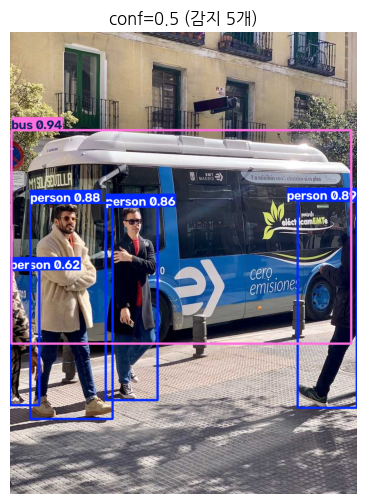

 conf=0.8  -> 4개 ['bus', 'person', 'person', 'person']


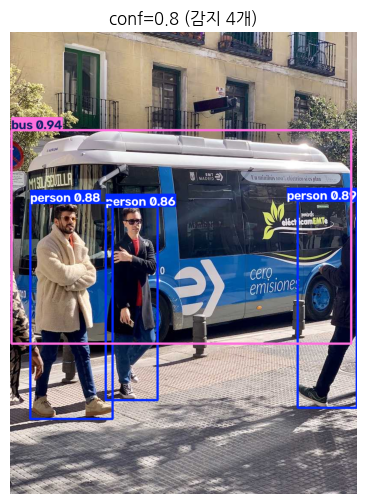

In [ ]:
# 셀 2. conf - 신뢰도 threshold (기본 0.25)

model = YOLO("yolo11n.pt")
print("\n[conf threshold]")
for conf in [0.1, 0.25, 0.5, 0.8]:
  r = model("bus.jpg", conf=conf, verbose=False)[0] # conf=이 값 이상만 채택
  names = [r.names[int(b.cls)] for b in r.boxes]
  print(f" conf={conf:<4} -> {len(r.boxes)}개 {names}")
  show(r, f"conf={conf} (감지 {len(r.boxes)}개)")

# conf threshold 낮추면 -> 많이 찾지만 헛것도 (recall↑)
# conf threshold 높이면 -> 확실한 것만 (precision↑)

# 신고 앱 = 놓치면 위험 -> 0.25-0.4 권장


[iou(NMS) threshold]
 iou=0.3  -> 5개


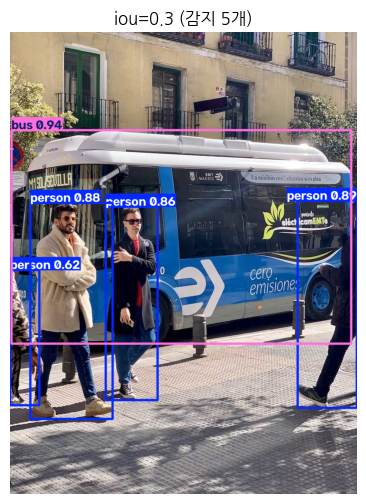

 iou=0.7  -> 5개


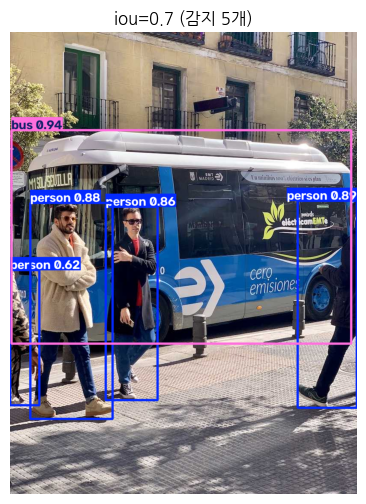

 iou=0.95 -> 8개


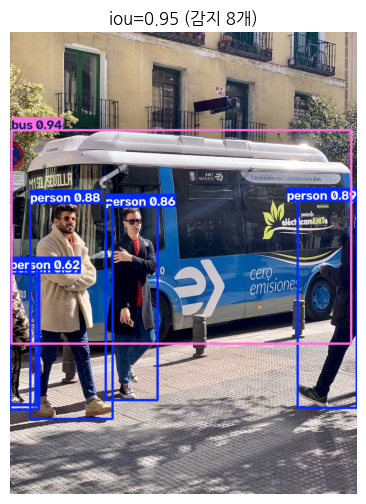

In [ ]:
# 셀 3. iou - NMS threshold(기본 0.7)
print("\n[iou(NMS) threshold]")
for iou_thr in [0.3, 0.7, 0.95]:
  r = model("bus.jpg", iou=iou_thr, verbose=False)[0] # iou=NMS 삭제 기준
  print(f" iou={iou_thr:<4} -> {len(r.boxes)}개")
  show(r, f"iou={iou_thr} (감지 {len(r.boxes)}개)")

#NMS: 1등과 iou 가 이 값 이상이면 같은 물체로 보고 삭제
# iou threshold 낮추면 -> 조금만 겹쳐도 삭제 -> 박스가 준다 (붙어 있는 물체를 하나로 합칠 위험)
# iou threshold 높이면 -> 많이 겹쳐야 삭제 -> 박스가 는다(한 물체에 중복 박스 위험)


[imgsz 입력 크기]
 imgsz=320   -> 감지 5개 | 117ms


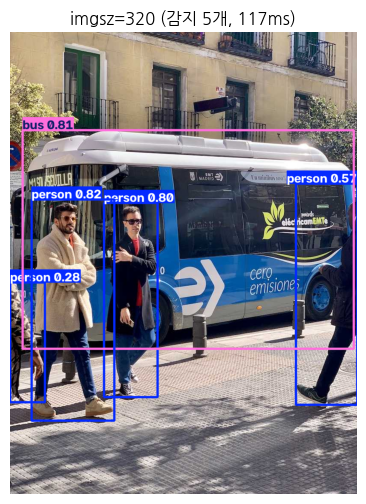

 imgsz=640   -> 감지 5개 | 81ms


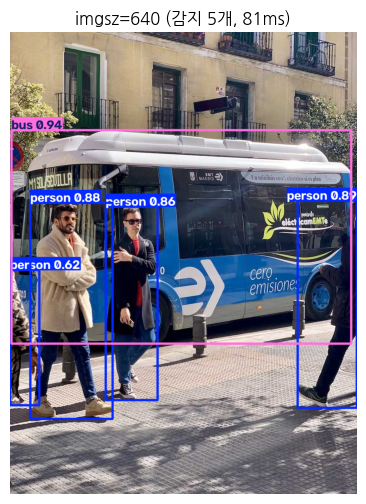

 imgsz=1280  -> 감지 4개 | 92ms


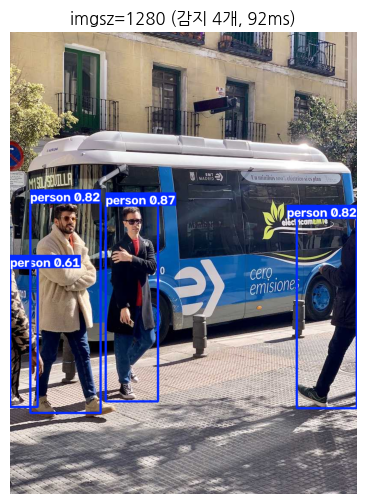

In [ ]:
# 셀 4. imgsz - 입력 크기 (기본 64)
print("\n[imgsz 입력 크기]")
for size in [320, 640, 1280]: # 입력 리사이즈 크기 3개
  t0 = time.time()
  r = model("bus.jpg", imgsz=size, verbose=False)[0]  # imgsz=내부 리사이즈 픽셀
  dt = (time.time() - t0) * 1000
  print(f" imgsz={size:<5} -> 감지 {len(r.boxes)}개 | {dt:.0f}ms")
  show(r, f"imgsz={size} (감지 {len(r.boxes)}개, {dt:.0f}ms)")

# 원거리에서 찍힌 포트홀처럼 수십 픽셀짜리 물체는 줄이면 뭉개져 사라진다. 이미지를 크게 해서 넣는다


[classes 필터]
 classes=[0](person만) -> 4개


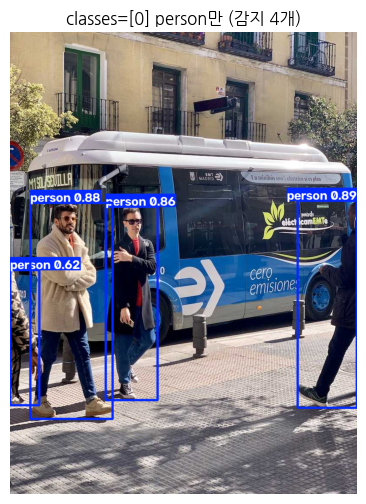

 classes=[5](bus만) -> 1개


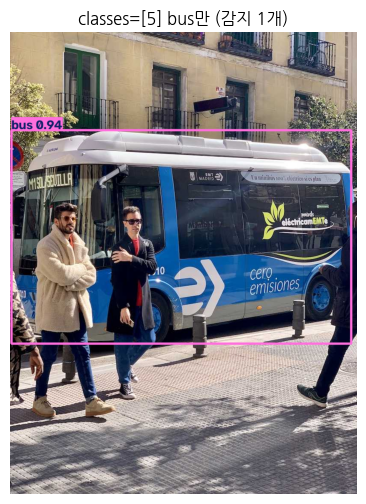


COCO 클래스는 총 80종: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck'] ...


In [ ]:
# 셀 5. classes - 원하는 클래스만 필터
print("\n[classes 필터]")

r = model("bus.jpg", classes=[0], verbose=False)[0]   # 사람만, classes=[]리스트로 여러 번호 지정 가능
print(f" classes=[0](person만) -> {len(r.boxes)}개")
show(r, f"classes=[0] person만 (감지 {len(r.boxes)}개)")

r = model("bus.jpg", classes=[5], verbose=False)[0]   # 버스만
print(f" classes=[5](bus만) -> {len(r.boxes)}개")
show(r, f"classes=[5] bus만 (감지 {len(r.boxes)}개)")

print(f"\nCOCO 클래스는 총 {len(model.names)}종:", list(model.names.values())[:8], "...")

# 추론 옵션 5개(모델크기/conf/iou/imgsz/classes)